In [2]:
# 1. Objective of Baseline Modeling
# 2. Import Libraries
# 3. Load Preprocessed Data
# 4. Evaluation Metrics for Imbalanced Classification
# 5. Logistic Regression Model
# 6. Random Forest Model
# 7. Baseline Results Comparison
# 8. Confusion Matrices
# 9. Classification Reports
# 10. Initial Observations
# 11. Limitations of Baseline Models

# 1. Objective of Baseline Modeling

The objective of this notebook is to build and evaluate baseline machine learning models for credit card fraud detection.

Since fraud detection is a highly imbalanced classification problem, baseline models are used to establish an initial performance benchmark before developing more advanced models such as XGBoost.

In this notebook, two baseline models are trained and evaluated:

- Logistic Regression
- Random Forest

These models are assessed using evaluation metrics that are appropriate for imbalanced datasets, including precision, recall, F1-score, ROC-AUC, and PR-AUC.

The results from this notebook will be used as a reference for comparison with more advanced approaches in later stages of the project.

# 2. Import Libraries

In this section, the required Python libraries for model training, evaluation, visualization, and result comparison are imported.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve
)

import warnings
warnings.filterwarnings("ignore")

# 3. Load Preprocessed Data

The preprocessed datasets from Notebook 2 are loaded in this section.

For baseline modeling, the following datasets are used:

- `X_train_scaled` and `y_train` for training
- `X_test_scaled` and `y_test` for evaluation

These datasets preserve the original class imbalance and allow us to measure baseline model performance under realistic conditions.

In [4]:
X_train_scaled = pd.read_csv("../data/processed/X_train_scaled.csv")
X_test_scaled = pd.read_csv("../data/processed/X_test_scaled.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

print("Training data shape:", X_train_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)
print("Training labels shape:", y_train.shape)
print("Testing labels shape:", y_test.shape)

Training data shape: (227845, 30)
Testing data shape: (56962, 30)
Training labels shape: (227845,)
Testing labels shape: (56962,)


In [5]:
print("Training class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training class distribution:
Class
0    227451
1       394
Name: count, dtype: int64

Testing class distribution:
Class
0    56864
1       98
Name: count, dtype: int64


# 4. Evaluation Metrics for Imbalanced Classification

Because the credit card fraud dataset is extremely imbalanced, accuracy alone is not a reliable evaluation metric.

For this project, the following metrics are used:

- **Precision**: Measures how many predicted fraud cases are actually fraud
- **Recall**: Measures how many actual fraud cases were successfully detected
- **F1-score**: Harmonic mean of precision and recall
- **ROC-AUC**: Measures the ability of the model to separate classes
- **PR-AUC**: Measures performance under class imbalance more effectively than ROC-AUC

Among these, recall and PR-AUC are especially important because missing fraud cases is more costly than incorrectly flagging legitimate transactions.

In [6]:
def evaluate_model(model_name, y_true, y_pred, y_prob):
    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "PR-AUC": average_precision_score(y_true, y_prob)
    }
    return results

# 5. Logistic Regression Model

Logistic Regression is used as the first baseline model because it is simple, interpretable, and commonly used for binary classification.

Although it may struggle with highly imbalanced data, it provides a useful benchmark for comparison with more complex models.

In [7]:
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [8]:
y_pred_lr = log_reg.predict(X_test_scaled)
y_prob_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

lr_results = evaluate_model("Logistic Regression", y_test, y_pred_lr, y_prob_lr)
lr_results

{'Model': 'Logistic Regression',
 'Accuracy': 0.9991397773954567,
 'Precision': 0.8266666666666667,
 'Recall': 0.6326530612244898,
 'F1-Score': 0.7167630057803468,
 'ROC-AUC': 0.9605494455801453,
 'PR-AUC': 0.7413820992780461}

# 6. Random Forest Model

Random Forest is used as the second baseline model because it is an ensemble learning method that can capture nonlinear relationships and interactions between features.

Compared to Logistic Regression, Random Forest is generally more flexible and may perform better on complex structured datasets.

In [9]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [10]:
y_pred_rf = rf_model.predict(X_test_scaled)
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

rf_results = evaluate_model("Random Forest", y_test, y_pred_rf, y_prob_rf)
rf_results

{'Model': 'Random Forest',
 'Accuracy': 0.9995962220427653,
 'Precision': 0.9411764705882353,
 'Recall': 0.8163265306122449,
 'F1-Score': 0.8743169398907104,
 'ROC-AUC': 0.9630272515590367,
 'PR-AUC': 0.8733910547021404}

# 7. Baseline Results Comparison

The performance of the baseline models is compared in a summary table using the selected evaluation metrics.

This comparison helps identify which model performs better under imbalanced classification conditions and provides a benchmark for future advanced models.

In [11]:
results_df = pd.DataFrame([lr_results, rf_results])
results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,Logistic Regression,0.999140,0.826667,0.632653,0.716763,0.960549,0.741382
1,Random Forest,0.999596,0.941176,0.816327,0.874317,0.963027,0.873391


In [12]:
results_df = results_df.sort_values(by="Recall", ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
1,Random Forest,0.999596,0.941176,0.816327,0.874317,0.963027,0.873391
0,Logistic Regression,0.999140,0.826667,0.632653,0.716763,0.960549,0.741382


In [13]:
results_df.to_csv("../reports/tables/baseline_model_results.csv", index=False)
print("Baseline results saved successfully.")

Baseline results saved successfully.


# 8. Confusion Matrices

Confusion matrices are used to visualize the number of:

- True Positives
- True Negatives
- False Positives
- False Negatives

This is especially important in fraud detection because false negatives represent fraud cases that were missed by the model.

In [14]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")
    plt.show()

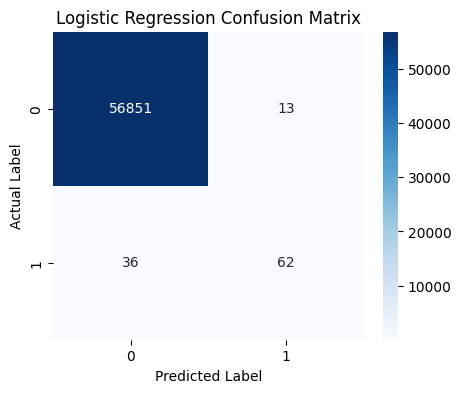

In [15]:
plot_confusion_matrix(y_test, y_pred_lr, "Logistic Regression Confusion Matrix")

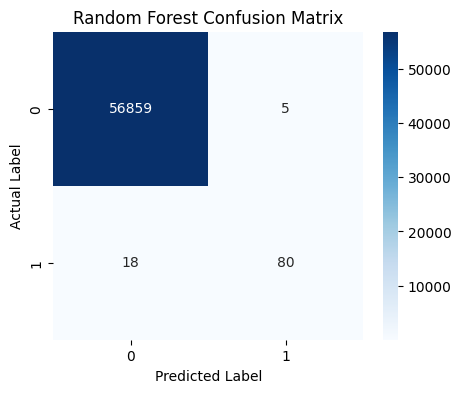

In [16]:
plot_confusion_matrix(y_test, y_pred_rf, "Random Forest Confusion Matrix")

# 9. Classification Reports

Classification reports provide a more detailed breakdown of precision, recall, and F1-score for each class.

This helps us better understand whether the model performs well on the minority fraud class, not just the majority normal class.

In [17]:
print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_lr, zero_division=0))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.63      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962



In [18]:
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf, zero_division=0))

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.82      0.87        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962



# 10. Initial Observations

Based on the baseline model results, several initial observations can be made:

1. Both models are likely to achieve very high accuracy because the dataset is dominated by legitimate transactions.
2. Accuracy alone is misleading in this problem and should not be used as the main decision metric.
3. The minority fraud class is much more difficult to detect than the majority normal class.
4. Recall is a critical metric because missed fraud cases are costly in real-world fraud detection systems.
5. Random Forest may capture more complex patterns than Logistic Regression, but both baseline models may still struggle with class imbalance.
6. These results justify the need for more advanced approaches such as imbalance handling, threshold tuning, and XGBoost in the next notebook.

In [19]:
print("Initial Observations:")
print("- Accuracy is high for both models due to class imbalance.")
print("- Recall and PR-AUC are more important than accuracy in fraud detection.")
print("- Baseline models provide a useful benchmark before advanced modeling.")

Initial Observations:
- Accuracy is high for both models due to class imbalance.
- Recall and PR-AUC are more important than accuracy in fraud detection.
- Baseline models provide a useful benchmark before advanced modeling.


In [20]:
results_df.to_csv("../reports/tables/baseline_model_results.csv", index=False)

In [21]:
import joblib
joblib.dump(log_reg, "../models/baseline/logistic_regression_baseline.pkl")
joblib.dump(rf_model, "../models/baseline/random_forest_baseline.pkl")

['../models/baseline/random_forest_baseline.pkl']

# 11. Limitations of Baseline Models

The baseline models in this notebook provide an important starting point, but they have several limitations:

1. They are trained on the original imbalanced dataset, which may bias the model toward the majority class.
2. Logistic Regression may be too simple to capture complex fraud patterns.
3. Random Forest may improve flexibility, but it still may not fully address extreme class imbalance.
4. The default classification threshold of 0.5 may not be optimal for fraud detection.
5. These models do not yet include explainability techniques such as SHAP.
6. More advanced methods such as SMOTE, class weighting, XGBoost, and threshold tuning are needed to improve fraud detection performance.

Therefore, the next stage of the project will focus on developing and optimizing more advanced models for better fraud detection.